In [2]:
!pip install pandas numpy matplotlib seaborn

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Path to the Airbnb dataset
airbnb_file_path = r'/content/AB_NYC_2019.csv'

# Read the dataset
airbnb_data = pd.read_csv(airbnb_file_path)

# Display the first few rows of the dataset
airbnb_data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


Read the YouTube Video Statistics Datasets

In [4]:
#Paths to the YouTube datasets
youtube_file_paths = [
    '/content/CAvideos.csv',
    '/content/DEvideos.csv',
    '/content/FRvideos.csv',
    '/content/GBvideos.csv',
    '/content/INvideos.csv',
    '/content/JPvideos.csv',
    '/content/KRvideos.csv',
    '/content/MXvideos.csv',
    '/content/RUvideos.csv',
    '/content/USvideos.csv'
]

# Read all YouTube datasets into a list of DataFrames
youtube_dataframes = [pd.read_csv(file_path,encoding='ISO-8859-1') for file_path in youtube_file_paths]

# Optionally concatenate all dataframes into one
youtube_data = pd.concat(youtube_dataframes, ignore_index=True)

# Display the first few rows of the YouTube dataset
youtube_data.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. BeyoncÃ©,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787425,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. BeyoncÃ© ...
1,0dBIkQ4Mz1M,17.14.11,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV,23,2017-11-13T17:00:00.000Z,"plush|""bad unboxing""|""unboxing""|""fan mail""|""id...",1014651,127794,1688,13030,https://i.ytimg.com/vi/0dBIkQ4Mz1M/default.jpg,False,False,False,STill got a lot of packages. Probably will las...
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146035,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...
3,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095828,132239,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...
4,2Vv-BfVoq4g,17.14.11,Ed Sheeran - Perfect (Official Music Video),Ed Sheeran,10,2017-11-09T11:04:14.000Z,"edsheeran|""ed sheeran""|""acoustic""|""live""|""cove...",33523622,1634130,21082,85067,https://i.ytimg.com/vi/2Vv-BfVoq4g/default.jpg,False,False,False,ð§: https://ad.gt/yt-perfect\nð°: https://...


Data Integrity Check

In [5]:
# Check for integrity of Airbnb dataset
print("Airbnb Dataset Info:")
print(airbnb_data.info())

print("\nYouTube Dataset Info:")
print(youtube_data.info())

Airbnb Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review

Missing Data Handling

In [6]:
# Check for missing data in Airbnb dataset
missing_airbnb = airbnb_data.isnull().sum()
print("\nMissing Values in Airbnb Dataset:\n", missing_airbnb)

# Print the columns of the Airbnb DataFrame to verify the names
print("Columns in Airbnb DataFrame:\n", airbnb_data.columns)

# Fill missing values or drop rows/columns based on context
airbnb_data['last_review'] = airbnb_data['last_review'].fillna(airbnb_data['last_review'].mode()[0])  # Fill with mode

# Drop 'reviews_per_month' if it exists; ignore if not found
airbnb_data.drop(columns=['reviews_per_month'], inplace=True, errors='ignore')  # Drop if too many missing

# Check for missing data in YouTube dataset
missing_youtube = youtube_data.isnull().sum()
print("\nMissing Values in YouTube Dataset:\n", missing_youtube)

# Fill or drop missing values based on analysis
youtube_data['description'] = youtube_data['description'].fillna('No description')  # Fill with placeholder


Missing Values in Airbnb Dataset:
 id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64
Columns in Airbnb DataFrame:
 Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availabilit

Duplicate Removal

In [7]:
# Remove duplicates in Airbnb dataset
duplicates_airbnb = airbnb_data.duplicated().sum()
print("\nDuplicate Rows in Airbnb Dataset: ", duplicates_airbnb)
airbnb_data.drop_duplicates(inplace=True)

# Remove duplicates in YouTube dataset
duplicates_youtube = youtube_data.duplicated().sum()
print("\nDuplicate Rows in YouTube Dataset: ", duplicates_youtube)
youtube_data.drop_duplicates(inplace=True)


Duplicate Rows in Airbnb Dataset:  0

Duplicate Rows in YouTube Dataset:  36417


Standardization

In [8]:
# Standardize column names for consistency
airbnb_data.columns = airbnb_data.columns.str.lower().str.replace(' ', '_')
youtube_data.columns = youtube_data.columns.str.lower().str.replace(' ', '_')

Outlier Detection

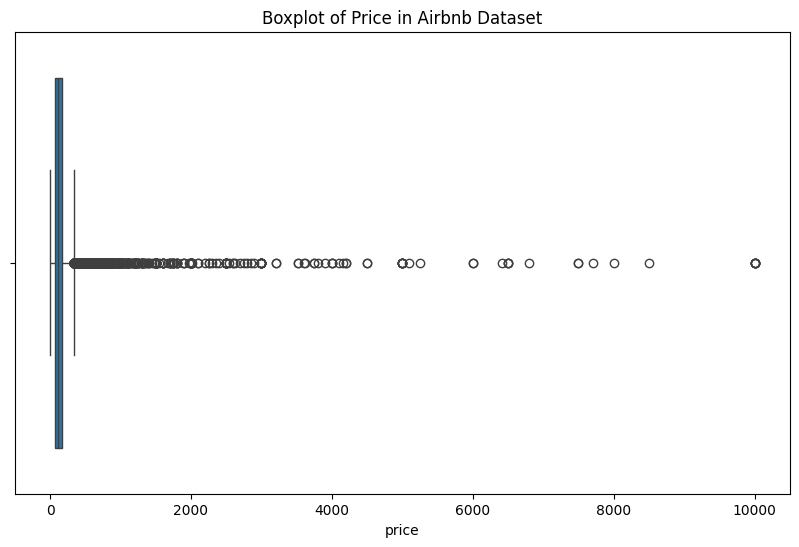

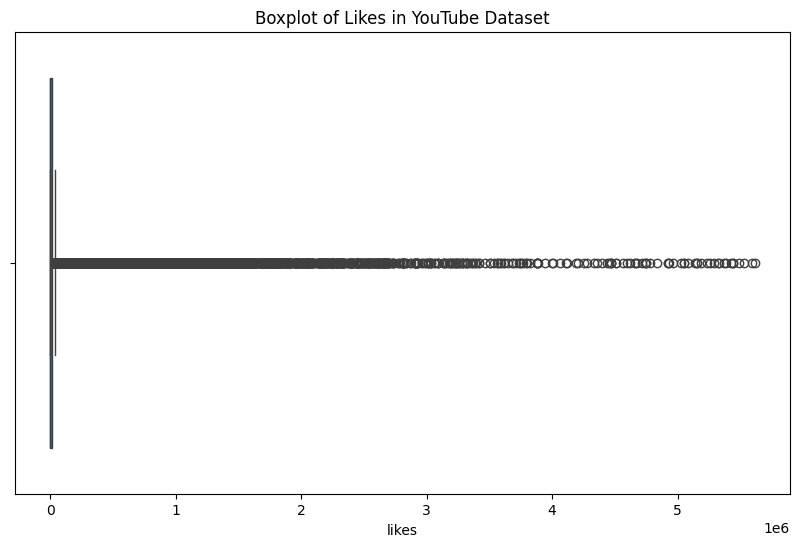

In [9]:
# Visualize outliers for the price in the Airbnb dataset using boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=airbnb_data['price'])
plt.title('Boxplot of Price in Airbnb Dataset')
plt.show()

# Remove outliers in Airbnb dataset (assuming price is normally distributed)
q1 = airbnb_data['price'].quantile(0.25)
q3 = airbnb_data['price'].quantile(0.75)
iqr = q3 - q1
airbnb_data = airbnb_data[(airbnb_data['price'] >= (q1 - 1.5 * iqr)) & (airbnb_data['price'] <= (q3 + 1.5 * iqr))]

# Visualize outliers for likes in the YouTube dataset
plt.figure(figsize=(10, 6))
sns.boxplot(x=youtube_data['likes'])
plt.title('Boxplot of Likes in YouTube Dataset')
plt.show()

# Remove outliers in YouTube dataset (assuming likes is normally distributed)
q1 = youtube_data['likes'].quantile(0.25)
q3 = youtube_data['likes'].quantile(0.75)
iqr = q3 - q1
youtube_data = youtube_data[(youtube_data['likes'] >= (q1 - 1.5 * iqr)) & (youtube_data['likes'] <= (q3 + 1.5 * iqr))]

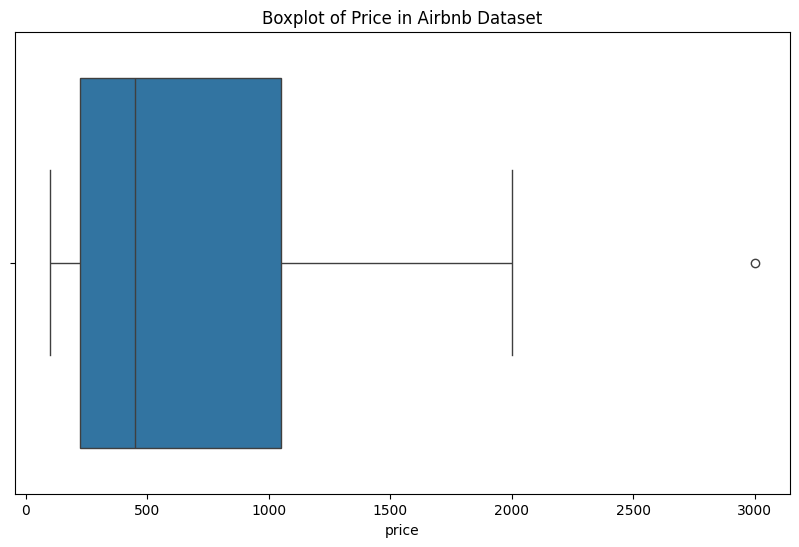

/tmp/ipython-input-10-3446911391.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['cluster'] = kmeans.fit_predict(scaled_data)


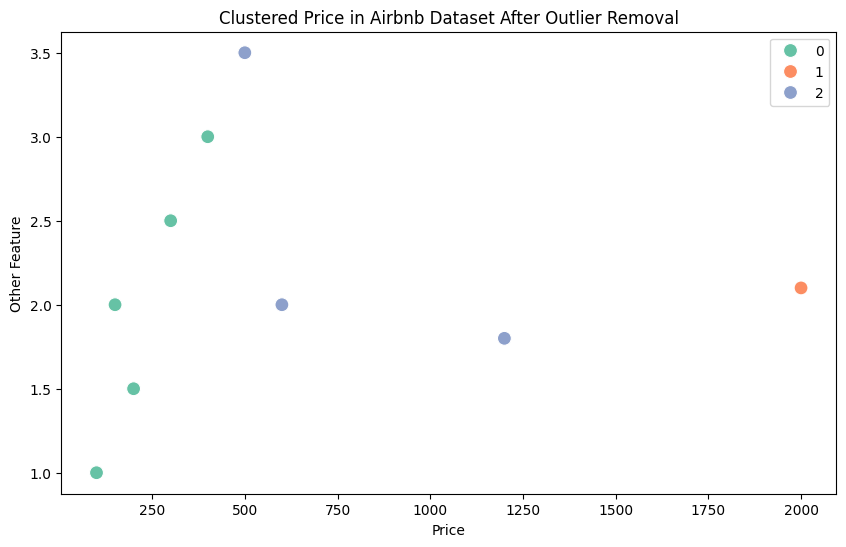

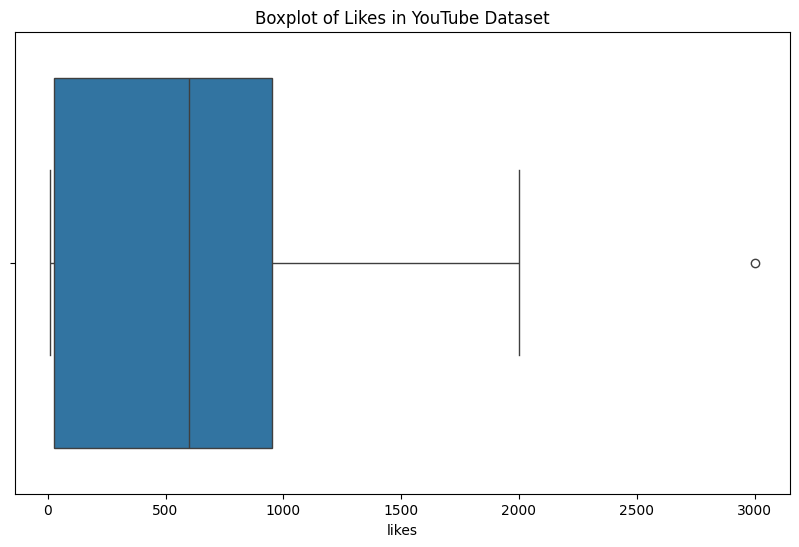

/tmp/ipython-input-10-3446911391.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['cluster'] = kmeans.fit_predict(scaled_data)


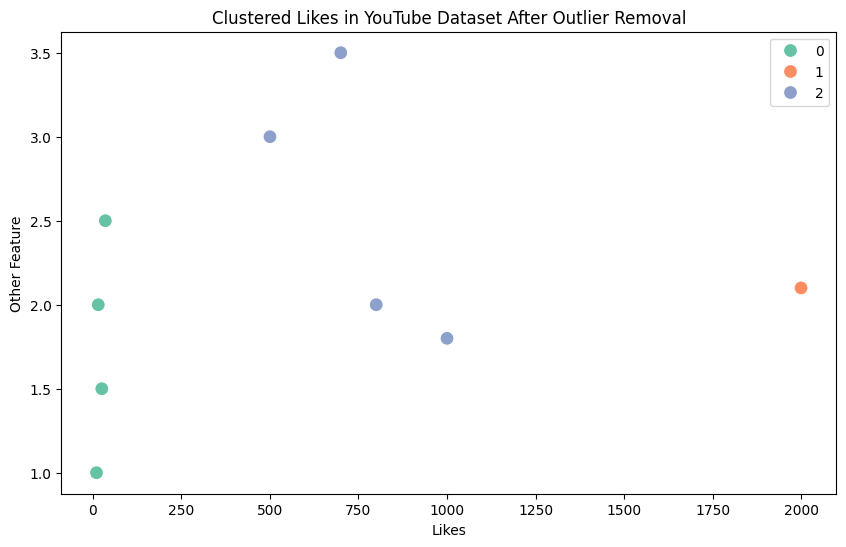

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Sample Airbnb Dataset (replace with your own data)
airbnb_data = pd.DataFrame({
    'price': [100, 150, 200, 300, 400, 500, 600, 1200, 2000, 3000],
    'other_feature': [1, 2, 1.5, 2.5, 3, 3.5, 2, 1.8, 2.1, 2.3]
})

# Sample YouTube Dataset (replace with your own data)
youtube_data = pd.DataFrame({
    'likes': [10, 15, 25, 35, 500, 700, 800, 1000, 2000, 3000],
    'other_feature': [1, 2, 1.5, 2.5, 3, 3.5, 2, 1.8, 2.1, 2.3]
})

# Function to visualize and remove outliers using boxplot and K-Means clustering
def visualize_and_remove_outliers(df, feature, dataset_name):
    # Visualize outliers using boxplot
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[feature])
    plt.title(f'Boxplot of {feature.capitalize()} in {dataset_name} Dataset')
    plt.show()

    # Calculate IQR and filter outliers
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    filtered_df = df[(df[feature] >= (q1 - 1.5 * iqr)) & (df[feature] <= (q3 + 1.5 * iqr))]

    # Perform K-Means clustering
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(filtered_df[[feature]])
    kmeans = KMeans(n_clusters=3, random_state=42)
    filtered_df['cluster'] = kmeans.fit_predict(scaled_data)

    # Plot clustered data
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=filtered_df, x=feature, y='other_feature', hue='cluster', palette='Set2', s=100)
    plt.title(f'Clustered {feature.capitalize()} in {dataset_name} Dataset After Outlier Removal')
    plt.xlabel(feature.capitalize())
    plt.ylabel('Other Feature')
    plt.legend()
    plt.show()

    return filtered_df

# Visualize and remove outliers for Airbnb dataset
airbnb_filtered = visualize_and_remove_outliers(airbnb_data, 'price', 'Airbnb')

# Visualize and remove outliers for YouTube dataset
youtube_filtered = visualize_and_remove_outliers(youtube_data, 'likes', 'YouTube')

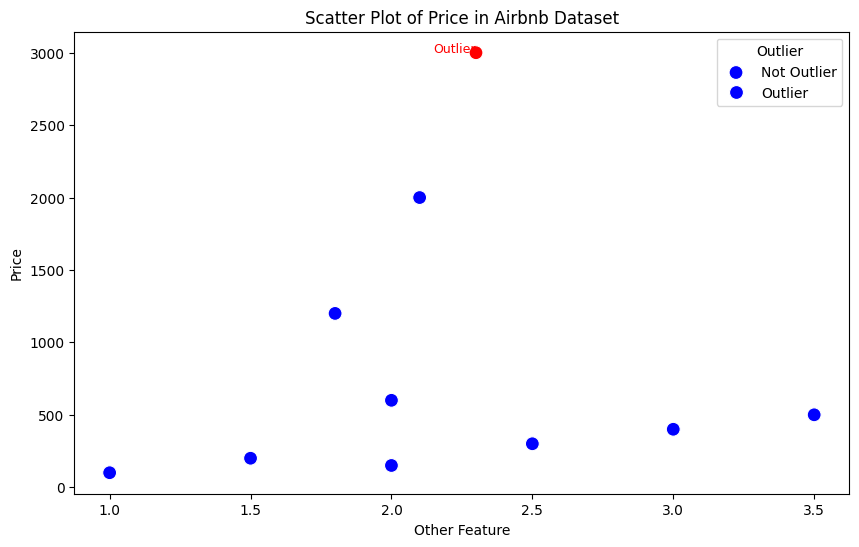

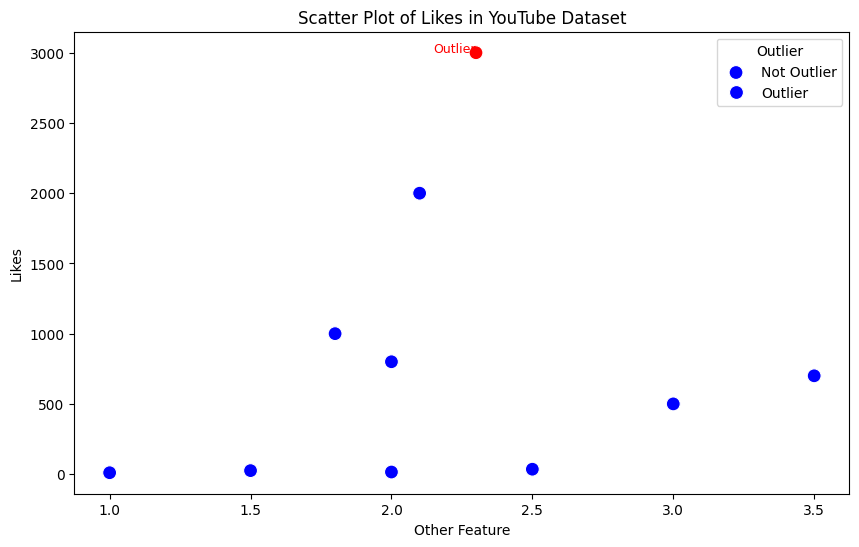

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sample Airbnb Dataset (replace with your own data)
airbnb_data = pd.DataFrame({
    'price': [100, 150, 200, 300, 400, 500, 600, 1200, 2000, 3000],
    'other_feature': [1, 2, 1.5, 2.5, 3, 3.5, 2, 1.8, 2.1, 2.3]
})

# Sample YouTube Dataset (replace with your own data)
youtube_data = pd.DataFrame({
    'likes': [10, 15, 25, 35, 500, 700, 800, 1000, 2000, 3000],
    'other_feature': [1, 2, 1.5, 2.5, 3, 3.5, 2, 1.8, 2.1, 2.3]
})

# Function to visualize outliers using scatter plot
def visualize_outliers_scatter(df, feature, dataset_name):
    # Calculate IQR to identify outliers
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1

    # Identify outliers
    outlier_condition = (df[feature] < (q1 - 1.5 * iqr)) | (df[feature] > (q3 + 1.5 * iqr))

    # Scatter plot with outliers highlighted
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='other_feature', y=feature, hue=outlier_condition, palette={True: 'red', False: 'blue'}, s=100)

    # Mark outliers with an additional label
    for i in range(len(df)):
        if outlier_condition[i]:
            plt.text(df['other_feature'][i], df[feature][i], 'Outlier', color='red', fontsize=9, ha='right')

    plt.title(f'Scatter Plot of {feature.capitalize()} in {dataset_name} Dataset')
    plt.xlabel('Other Feature')
    plt.ylabel(feature.capitalize())
    plt.legend(title='Outlier', labels=['Not Outlier', 'Outlier'])
    plt.show()

# Visualize outliers for Airbnb dataset
visualize_outliers_scatter(airbnb_data, 'price', 'Airbnb')

# Visualize outliers for YouTube dataset
visualize_outliers_scatter(youtube_data, 'likes', 'YouTube')

Save Cleaned Data

In [13]:
# Save cleaned datasets
cleaned_airbnb_file_path = '/content/AB_NYC_2019.csv'
airbnb_data.to_csv(cleaned_airbnb_file_path, index=False)

cleaned_youtube_file_path = '/content/Cleaned_Youtube_Videos.csv'
youtube_data.to_csv(cleaned_youtube_file_path, index=False)